# Objective :
### Test which timing (3 hr, 6 hrs, 18 hrs) for sending cart abandonment emails leads to highest return-to-purchase rate.

In [2]:
import pandas as pd
df=pd.read_csv("user_return_data.csv")
# Show the first few rows
print(df.head())


  user_id group  returned  delay_to_return_hr
0   1hr_0   1hr     False                 NaN
1   1hr_1   1hr     False                 NaN
2   1hr_2   1hr     False                 NaN
3   1hr_3   1hr     False                 NaN
4   1hr_4   1hr      True            0.169596


In [10]:
# conduct power analysis 
from statsmodels.stats.power import TTestPower
power_analysis = TTestPower()  
sample_size = power_analysis.solve_power(effect_size=0.2, alpha=0.05, power=0.8, alternative='larger')
print(f"Minimum sample size needed for the test: {sample_size:.0f}")

Minimum sample size needed for the test: 156


In [11]:
#count of users per group
group_counts = df['group'].value_counts()
print("Count of users per group:")
print(group_counts)

Count of users per group:
group
1hr     1000
6hr     1000
24hr    1000
Name: count, dtype: int64


In [ ]:
#Return-to-purchase rates by timing group.

return_rates = df[df['returned'] == True].groupby('group')['user_id'].count() / df.groupby('group')['user_id'].count()
print("Return rates by group:")
print(return_rates)



Return rates by group:
group
1hr     0.262
24hr    0.290
6hr     0.309
Name: user_id, dtype: float64


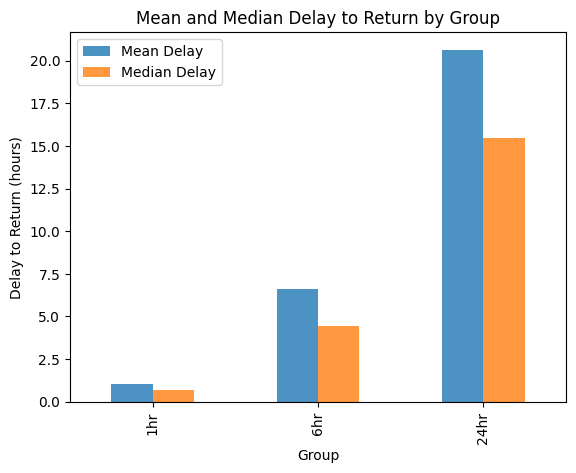

In [18]:
# Mean/median delay_to_return_hr in each group
import matplotlib.pyplot as plt

mean_delay = df.groupby('group')['delay_to_return_hr'].mean()
median_delay = df.groupby('group')['delay_to_return_hr'].median()

# Combine into a DataFrame for side-by-side bars
desired_order = ['1hr', '6hr', '24hr']
delay_df = delay_df.reindex(desired_order)

# Plot side by side
delay_df.plot(kind='bar', alpha=0.8)
plt.title('Mean and Median Delay to Return by Group')
plt.xlabel('Group')
plt.ylabel('Delay to Return (hours)')
plt.legend()
plt.show()


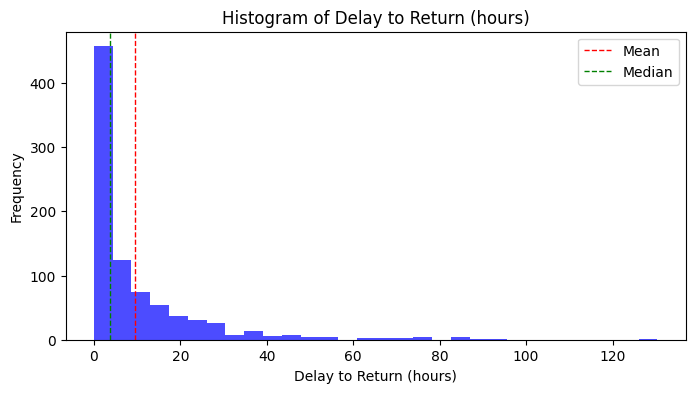

Mean delay to return: 9.64260086058082
Median delay to return: 3.7269196767547


In [21]:
# plot histogram of delay_to_return_hr
plt.figure(figsize=(8, 4))
plt.hist(df['delay_to_return_hr'], bins=30, color='blue', alpha=0.7)
plt.title('Histogram of Delay to Return (hours)')
plt.xlabel('Delay to Return (hours)')
plt.ylabel('Frequency')
plt.axvline(df['delay_to_return_hr'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df['delay_to_return_hr'].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
plt.legend()
plt.show()
print("Mean delay to return:", df['delay_to_return_hr'].mean())
print("Median delay to return:", df['delay_to_return_hr'].median())


## Statistical Testing

In [27]:
# Chi-Square Test of Independence : Check if return rate is independent of timing
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['group'], df['returned'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)
print('Contingency_table:')
print(contingency_table)
print(f"Chi-Square Test: chi2 = {chi2:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Reject the null hypothesis: Return rate is dependent on timing group.")
else:
    print("Fail to reject the null hypothesis: Return rate is independent of timing group.")


Contingency_table:
returned  False  True 
group                 
1hr         738    262
24hr        710    290
6hr         691    309
Chi-Square Test: chi2 = 5.4635, p-value = 0.0651
Fail to reject the null hypothesis: Return rate is independent of timing group.


returned,False,True
group,,
1hr,738,262
24hr,710,290
6hr,691,309
